# Evaluation, Grad-CAM, and Error Analysis

A high accuracy score on a balanced binary task is a weak result on its own. It cannot
distinguish a model that recognizes animals from one that has latched onto a spurious
correlation (indoor-vs-outdoor backgrounds, say, or the presence of a collar), and it
says nothing about which images remain hard.

This notebook attacks both questions:

* **Per-class precision, recall, and F1**, plus a confusion matrix, to see whether errors are symmetric or the model systematically favors one class.
* **Grad-CAM**, to visualize which image regions actually drive each prediction. This is the single most informative addition here: it is the difference between reporting that a model works and showing *why* it works.
* **Error analysis on the most confidently wrong predictions**, which is where mislabeled and genuinely ambiguous images surface.

Everything below uses the best checkpoint from notebook 02 and the held-out **test**
split from notebook 01, which is the one set of images that has been touched by
neither training nor checkpoint selection. Notebook 02 chose its checkpoint by
validation loss, so the validation score is a maximum taken over every epoch and is
biased upward. The numbers below are not.

## Imports and setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from catsdogs.dataset import IMAGENET_MEAN, IMAGENET_STD, CatsDogsDataset, build_transforms
from catsdogs.evaluate import (
    compute_confusion_matrix,
    most_confident_errors,
    per_class_metrics,
    predict_probabilities,
)
from catsdogs.gradcam import GradCAM, overlay_heatmap
from catsdogs.model import build_model

CLASS_NAMES = ["cat", "dog"]
PROCESSED_DIR = Path("../data/processed")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The model is rebuilt with `pretrained=False` before loading the checkpoint, since there
is no sense downloading ImageNet weights only to immediately overwrite them with our
fine-tuned ones. The evaluation transform is deterministic, which matters here: Grad-CAM
and the error analysis both need the *same* image every time they index into the
dataset.

In [2]:
model = build_model(num_classes=2, pretrained=False)
model.load_state_dict(torch.load("../outputs/checkpoints/best.pt", map_location=device))
model.to(device)

test_df = pd.read_csv(PROCESSED_DIR / "test_split.csv")
test_paths = [Path(p) for p in test_df["path"]]
test_labels = np.array(test_df["label"])

test_dataset = CatsDogsDataset(test_paths, list(test_labels), build_transforms(train=False))
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"evaluating on {len(test_dataset)} held-out images")

evaluating on 3744 held-out images


## Metrics

`predict_probabilities` returns softmax outputs rather than hard labels. Keeping the
probabilities is what makes the error analysis at the end possible: ranking mistakes by
confidence requires knowing how confident the model was, which `argmax` discards.

On a balanced dataset, accuracy, macro precision, and macro recall will be close
together. The per-class breakdown is the informative part: a precision/recall imbalance
*within* a class means the model has an asymmetric bias, mistaking one class for the
other more readily than the reverse.

In [3]:
probs = predict_probabilities(model, test_loader, device)
preds = probs.argmax(axis=1)

accuracy = (preds == test_labels).mean()
print(f"accuracy: {accuracy:.4f}")

pd.DataFrame(per_class_metrics(test_labels, preds), index=CLASS_NAMES).round(4)

accuracy: 0.9893


,precision,recall,f1
cat,0.9883,0.9904,0.9893
dog,0.9904,0.9882,0.9893


## Confusion matrix

With only two classes the confusion matrix holds four numbers, but it answers a question
the metrics table does not pose directly: are the off-diagonal counts balanced?

Roughly equal off-diagonals mean the model is simply wrong occasionally. A lopsided
matrix, with many more cats called dogs than the reverse, points to a systematic bias,
and since notebook 01 confirmed the classes are balanced and the split was stratified,
such a bias could not be blamed on the data distribution.

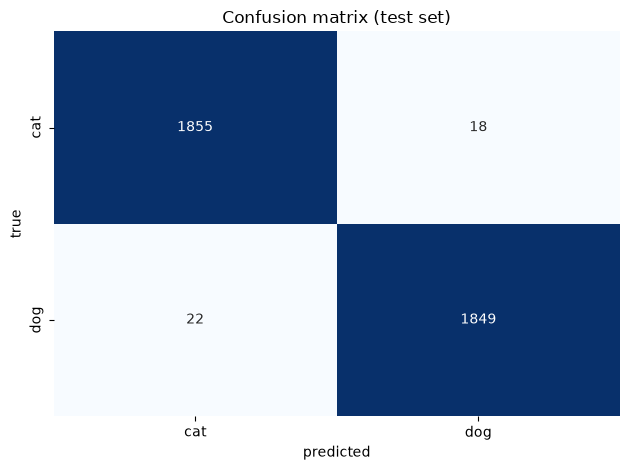

cats misread as dogs: 18
dogs misread as cats: 22


In [4]:
cm = compute_confusion_matrix(test_labels, preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=False,
)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix.png", dpi=150)
plt.show()

print(f"cats misread as dogs: {cm[0, 1]}")
print(f"dogs misread as cats: {cm[1, 0]}")

## Grad-CAM: what is the model looking at?

Grad-CAM (Gradient-weighted Class Activation Mapping) answers a question metrics cannot:
*which pixels mattered?*

The mechanism is short enough to state precisely. Take the score for the predicted class
and backpropagate it to the final convolutional block's activation maps. Average each
channel's gradient spatially. That average is how much the class score would change if
that channel were more active, so it serves as the channel's importance weight. Sum the
activation maps weighted by those importances, discard negative contributions with a
ReLU, and upsample the result to the input size. Regions that survive are the regions
that pushed the prediction toward the chosen class.

`src/catsdogs/gradcam.py` implements this directly with forward and backward hooks
rather than pulling in a Grad-CAM library. For a case study the implementation *is* part
of the demonstration, and it keeps the dependency list short.

One honest caveat about resolution: `layer4` outputs a 7x7 spatial grid for a 224x224
input, so each heatmap cell covers a 32x32 pixel region. These maps localize to "the
animal's head" but never to fine detail, and the smooth blobs are an artifact of
bilinear upsampling, not evidence of smooth attention. Reading them as precise pixel
attributions would be overinterpreting.

In [5]:
cam = GradCAM(model, model.layer4[-1])


def to_display_image(tensor: torch.Tensor) -> np.ndarray:
    """Undo ImageNet normalization so a tensor can be shown as an image."""
    array = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    return np.clip(array * IMAGENET_STD + IMAGENET_MEAN, 0, 1)


def label_text(idx: int) -> str:
    return (
        f"true={CLASS_NAMES[test_labels[idx]]}, "
        f"pred={CLASS_NAMES[preds[idx]]} ({probs[idx, preds[idx]]:.2f})"
    )

Correct predictions first, as a baseline for what healthy attention looks like. Two
cats and two dogs, deliberately, since taking whichever examples happen to come first
would sample a single class and make the baseline useless for comparing the two.

Expect the heat to concentrate on the animal, typically the face, rather than on
background. If it consistently landed on furniture, grass, or image borders, high
accuracy would be a warning sign rather than a success: the model would be exploiting
dataset artifacts that will not survive contact with new photographs.

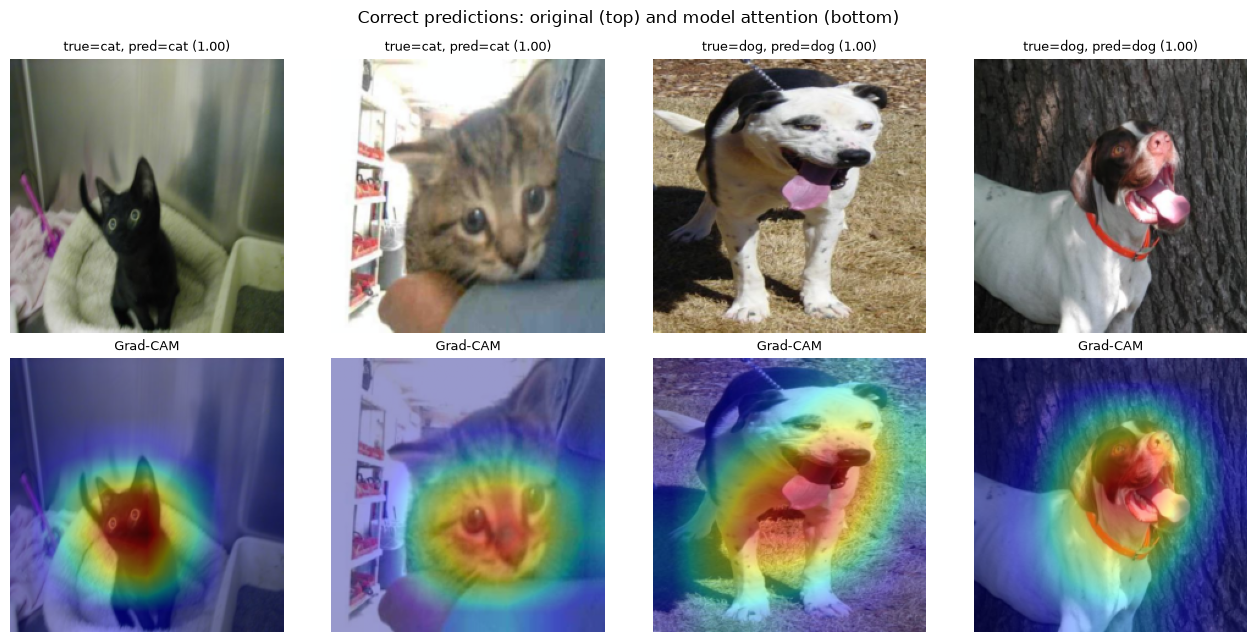

In [6]:
# take two of each class rather than the first four matches, which would
# otherwise all come from whichever class happens to sort first
correct_idx = np.concatenate(
    [np.flatnonzero((preds == test_labels) & (test_labels == c))[:2] for c in (0, 1)]
)

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for col, idx in enumerate(correct_idx):
    image = test_dataset[idx][0].unsqueeze(0).to(device)
    display = to_display_image(image)
    heatmap = cam(image, target_class=int(preds[idx]))

    axes[0, col].imshow(display)
    axes[0, col].set_title(label_text(idx), fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay_heatmap(display, heatmap))
    axes[1, col].set_title("Grad-CAM", fontsize=9)
    axes[1, col].axis("off")

fig.suptitle("Correct predictions: original (top) and model attention (bottom)")
plt.tight_layout()
plt.savefig("../outputs/figures/gradcam_correct.png", dpi=150)
plt.show()

Now the same treatment for mistakes. These are the more interesting maps, because they
separate two very different kinds of failure: the model looked at the right subject and
still misjudged it, or it looked somewhere unhelpful entirely. Only the second is really
an attention problem, and the distinction is invisible to any metric.

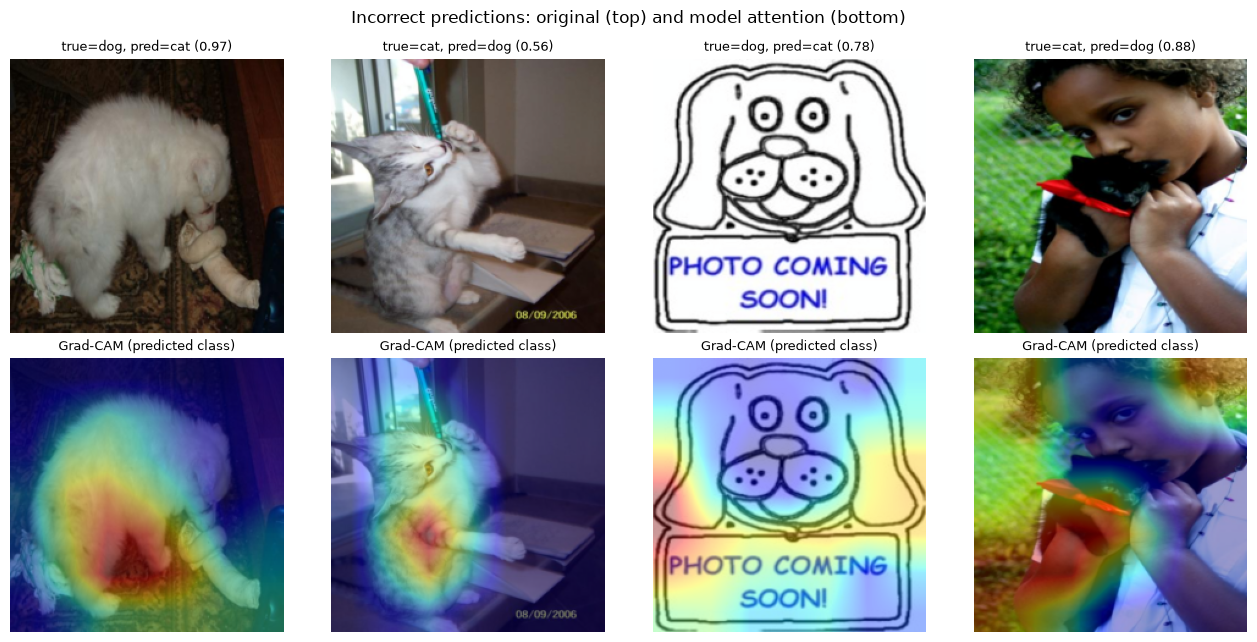

In [7]:
wrong_idx = np.flatnonzero(preds != test_labels)[:4]

fig, axes = plt.subplots(2, len(wrong_idx), figsize=(13, 6.5))
for col, idx in enumerate(wrong_idx):
    image = test_dataset[idx][0].unsqueeze(0).to(device)
    display = to_display_image(image)
    heatmap = cam(image, target_class=int(preds[idx]))

    axes[0, col].imshow(display)
    axes[0, col].set_title(label_text(idx), fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay_heatmap(display, heatmap))
    axes[1, col].set_title("Grad-CAM (predicted class)", fontsize=9)
    axes[1, col].axis("off")

fig.suptitle("Incorrect predictions: original (top) and model attention (bottom)")
plt.tight_layout()
plt.savefig("../outputs/figures/gradcam_incorrect.png", dpi=150)
plt.show()

## Error analysis: the most confidently wrong predictions

Not all mistakes are equally informative. An image the model called a dog with 51%
confidence is a coin flip near the decision boundary and tells us little. An image it
called a dog with 99% confidence *and got wrong* is a real failure of the learned
representation, or a mislabeled file.

`most_confident_errors` ranks misclassified examples by the probability assigned to
the wrong class, surfacing the worst cases first. This is the cell to read closely,
because a web-scraped dataset of this kind tends to hide a few pathological images
in the tail: frames containing both a cat and a dog, animals barely visible in the
shot, and occasionally files that are not animal photographs at all. Whether any of
those actually appear here is exactly what the figure below settles.

Each image is shown with its attention map underneath, because the two questions are
only worth asking together. Knowing that the model was 99% sure and wrong says
nothing about *why*; the map separates a confident misreading of the animal from a
confident reading of something that is not the animal at all. The map is computed for
the class the model chose, not the correct one, so it shows the evidence the model
believed it had rather than the evidence it missed.

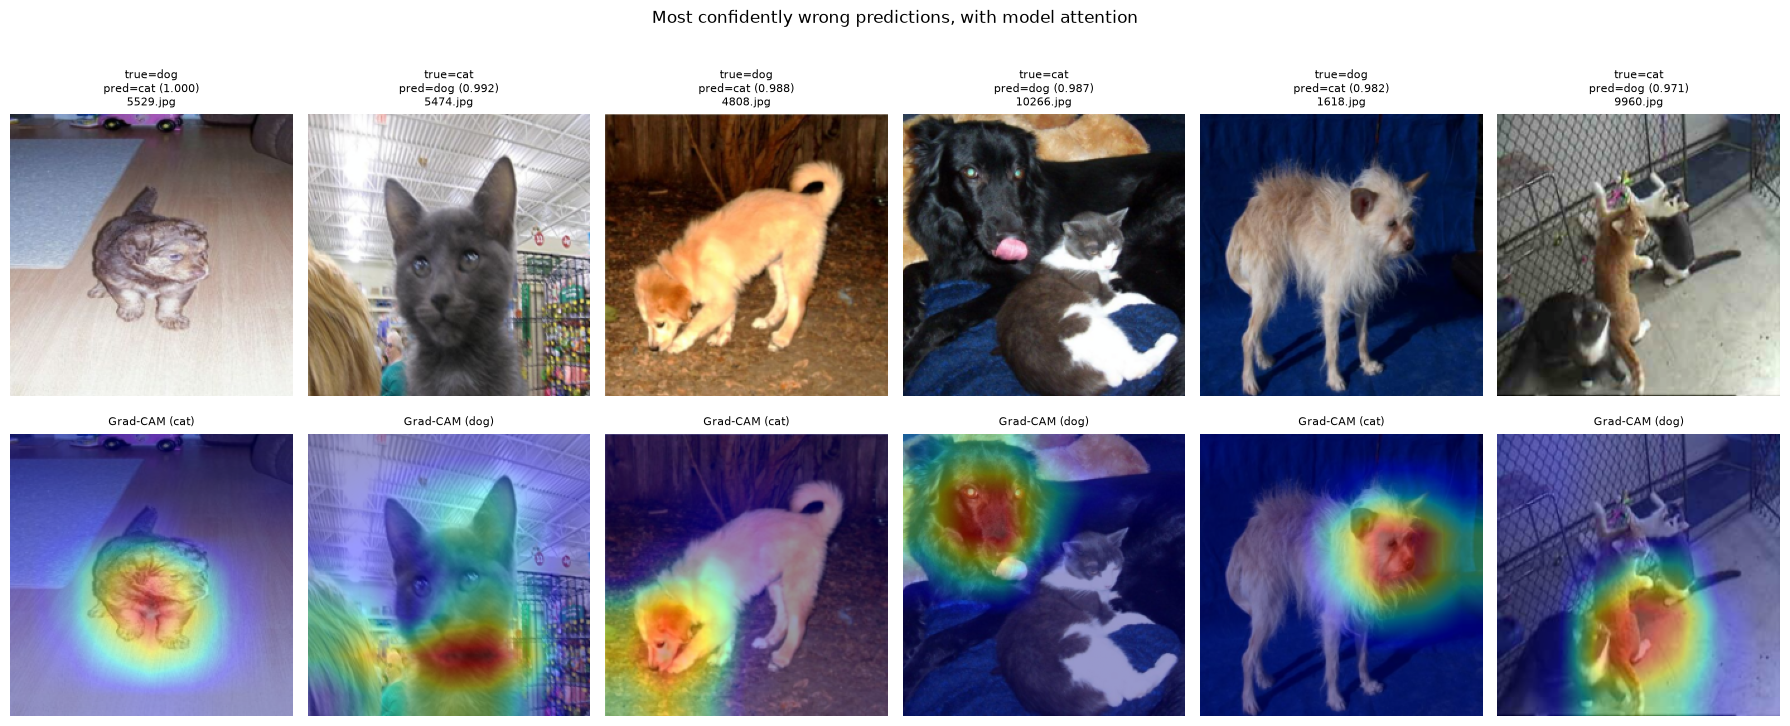

,file,true,predicted,confidence
0,5529.jpg,dog,cat,0.999588
1,5474.jpg,cat,dog,0.991921
2,4808.jpg,dog,cat,0.988116
3,10266.jpg,cat,dog,0.987395
4,1618.jpg,dog,cat,0.981731
5,9960.jpg,cat,dog,0.971198


In [8]:
worst_idx = most_confident_errors(test_labels, probs, k=6)

fig, axes = plt.subplots(2, len(worst_idx), figsize=(3 * len(worst_idx), 7.4))
for col, idx in enumerate(worst_idx):
    image = test_dataset[idx][0].unsqueeze(0).to(device)
    display = to_display_image(image)
    # the map is taken for the class the model wrongly chose, so it answers
    # "what made it say this?" rather than "where was the correct evidence?"
    heatmap = cam(image, target_class=int(preds[idx]))

    axes[0, col].imshow(display)
    axes[0, col].set_title(
        f"true={CLASS_NAMES[test_labels[idx]]}\n"
        f"pred={CLASS_NAMES[preds[idx]]} ({probs[idx, preds[idx]]:.3f})\n"
        f"{test_paths[idx].name}",
        fontsize=8,
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay_heatmap(display, heatmap))
    axes[1, col].set_title(f"Grad-CAM ({CLASS_NAMES[preds[idx]]})", fontsize=8)
    axes[1, col].axis("off")

fig.suptitle("Most confidently wrong predictions, with model attention")
# six columns leave each row short on height, so reserve room for the suptitle
# and open the gap between rows to keep every title clear of the images
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.subplots_adjust(hspace=0.10)
plt.savefig("../outputs/figures/misclassified_examples.png", dpi=150)
plt.show()

pd.DataFrame(
    {
        "file": [test_paths[i].name for i in worst_idx],
        "true": [CLASS_NAMES[test_labels[i]] for i in worst_idx],
        "predicted": [CLASS_NAMES[preds[i]] for i in worst_idx],
        "confidence": [probs[i, preds[i]] for i in worst_idx],
    }
)

### Discussion

Having the attention map under each of these six changes what can be said about them,
so it is worth going through them with the maps in hand.

**One is label noise, and the map settles it.** `10266.jpg` is labeled cat, and the
model called it dog at 0.987. The frame holds a black dog and a cat curled up against
it, with the dog taking most of the upper half of the shot, and the heat sits squarely
on the dog's face while the cat stays cold. The model was not confused: it found a dog
in an image labeled cat and said so. This is the clearest possible demonstration that
the file is an error only by convention, and it is the kind of verdict the raw image
alone could not deliver, since without the map the same picture is equally consistent
with the model having latched onto the cat and blundered.

**Four are genuine ambiguity**, and a theme runs through them:

* `5529.jpg`, the most confident error in the test set at 0.9996: a small fluffy puppy shot from above with its head lowered, so the face is essentially unavailable. Attention sits on the compact body, which is about as cat-shaped as a dog gets.
* `4808.jpg`: a pale cream dog nosing the ground, head down and face hidden, with the heat on the lowered head.
* `1618.jpg`: a small wiry-haired terrier standing in profile, and the easiest of the six to sympathize with. It is slight and narrow-waisted, with large triangular ears set wide on the head and tufted fur bristling around the muzzle in a way that reads as a cat's ruff. Attention sits on the face, which is exactly where those cat-like features are concentrated. Shown this photograph at a glance, a person could make the same call.
* `9960.jpg`: three cats in a shelter enclosure at low resolution, two of them rearing up on their hind legs. The count is probably the difficulty in itself. The model emits one label for the whole frame, but there are three candidate subjects here and nothing to indicate which one the label is about. Attention settles on one of them, and rearing on the hind legs is a dog-typical posture, so both the subject it picked and the pose it saw push away from cat.

That last one shares a problem with the label-noise case above, reached from a
different direction: one image, several animals, one label. `10266.jpg` has two species
in frame and `9960.jpg` has three animals of a single species, and in both the model is
asked to summarize a crowded picture with one answer. It is worth separating that from
the rest, because no amount of training fixes an image whose label was never well
defined.

In three of these four the animal's face is turned away, lowered, or too small to
resolve. That matches the correct-prediction maps above, where heat lands on the muzzle
and eyes every single time, for cats and dogs alike. The model is strongly face-driven,
so photographs that deny it a face are exactly where it fails, and the maps show it
hunting in the right place and coming up short.

**One is a real model weakness, and here the map is diagnostic.** `5474.jpg` is a grey
kitten facing the camera in a pet store, unmistakably a cat: large pointed ears,
whiskers, a full frontal view in good light. It was called dog at 0.992. The map shows
attention concentrated low, on the muzzle and chest, with the eyes and ears left in the
cool part of the map. The one image in this set where the face was fully available is
also the one where the model declined to use it, and it got the answer wrong. That is a
specific, nameable defect rather than a shrug.

**The cross-cutting finding is what the six have in common.** In every one of them,
attention is on an animal. Not one is a case of the model reading the background. The
failures at the top of the confidence ranking are failures of recognition, not of
localization.

That contrast is sharpest against the Grad-CAM panel on the first four errors above,
which is a lower-confidence sample and behaves differently. Two of those four also
attend to the animal. The other two do not, and they are the interesting ones:

* One, at 0.88, is a small black kitten held up by a child against a lawn. The child occupies most of the frame, and the heat spreads over the grass and the child rather than over the kitten.
* The other, at 0.78, **is not a photograph at all.** It is a line-drawing placeholder graphic reading "PHOTO COMING SOON!", of the kind an adoption listing shows before a real picture is uploaded. The attention map has nothing to land on and smears around the borders.

That second file deserves dwelling on, because it is a data-quality problem nothing
earlier in this project could have caught. The integrity pass in notebook 01 rejects
files that fail to decode; this one decodes perfectly, because it is a perfectly valid
image. It is simply not a photograph of a dog. The confident-error ranking pointed at
it and the attention map explained it, which is a use for Grad-CAM beyond model
debugging: it audits the data.

**A caution about reading too much into six images.** An earlier run of this notebook,
before the training seed was fixed, produced a different set of confident errors and
with them an apparent directional bias, most of the worst errors being cats called
dogs. That pattern did not survive re-training. This run splits three and three, and
the confusion matrix leans the other way, 18 cats read as dogs against 22 dogs read as
cats. The aggregate error count was stable across the two runs, 44 and then 40; which
specific images landed in the tail was not. The structural findings did reproduce:
attention on the face when correct, attention on the animal for the most confident
errors, and the same multi-animal file surfacing near the top both times. Those are
worth trusting. Counts over six examples are not, which is the reason the seed now
exists.

**What this implies for the ceiling.** At 98.93% test accuracy, 40 errors remain out of
3,744, and the maps say they are not all the same kind of thing. At least one is not a
dog photograph at all, at least one contains both animals, and several are images where
the animal's face is simply not visible. Buying accuracy with a larger backbone or a
longer schedule would be chasing a mixture of noise and genuinely unresolvable pictures.
The interventions the evidence actually supports are narrower: screen the training data
for non-photographs, and loosen the model's reliance on the face by augmenting with
crops that remove it, so body shape and texture have to carry more of the decision.
Neither is a conclusion the accuracy number on its own could have suggested.

## Closing notes

The pipeline here is a fine-tuned ResNet18 reaching 98.93% accuracy on a held-out
test set that neither training nor checkpoint selection ever saw, evaluated past that
headline number in three ways: per-class metrics and a confusion matrix to check for
asymmetric bias, Grad-CAM to ask whether the model attends to the animal rather than to
its surroundings, and a confidence-ranked error analysis to separate label noise from
genuine model weakness.

The Grad-CAM step is what turned a good score into something more useful than a score.
It showed that the model is face-driven, that its most confident errors are recognition
failures rather than attention failures, that one of its errors is a clear case of
looking at a person and a lawn instead of the animal, and that one of the files in the
dataset is not a photograph of an animal at all. None of that is visible in 98.93%.

That last distinction is the practical payoff. When a portion of the remaining error is
mislabeled or truly ambiguous data, the honest conclusion is that additional training or
a deeper backbone would chase noise, not signal, and knowing where that ceiling sits is
more useful than another decimal place of accuracy.